
# mercados + series de tiempo + research,
## semana 03 
> pregunta fundamental para cualquier alpha: ¿la información disponible hoy realmente ayuda a predecir mañana?

Conditional expectation como definición de señal. Supón que un activo tiene $ E[r_{t+1}]=0 $ , pero observas una variable $ X_t\in\{-1,+1\} $. De 1,000 observaciones obtienes:

$$ E[r_{t+1}\mid X_t=+1]=+6\text{ bps}, \qquad E[r_{t+1}\mid X_t=-1]=-4\text{ bps}. $$

Además,

$$ P(X_t=+1)=0.40,\qquad P(X_t=-1)=0.60. $$

Calcula mediante la ley de esperanza total:

$$ E[r_{t+1}] = \sum_x E[r_{t+1}\mid X_t=x]P(X_t=x). $$

Después responde: ¿es posible que $ E[r_{t+1}] $  sea aproximadamente cero y aun así $ (X_t $  contenga información predictiva? Explica qué diferencia conceptual existe entre

$$ E[r_{t+1}] \quad\text{y}\quad E[r_{t+1}\mid\mathcal F_t]. $$

Ésta es la conexión matemática:  <b> un alpha no intenta necesariamente demostrar que los retornos tienen media distinta de cero; intenta encontrar información disponible en $ t $ que cambie la distribución condicional de $ r_{t+1} $ </b>

,observaciones,retorno_condicional,volatilidad,P(x_t),contribucion
x_t,,,,,
-1,6048,-0.03%,1.00%,60.48%,-0.0165%
1,3952,0.08%,1.01%,39.52%,0.0300%


Media directa de r_(t+1): 0.0136%
Media por esperanza total: 0.0136%
Media teórica: -0.0000%
Media condicional si x_t =  1: 0.06% = +6 bps
Media condicional si x_t = -1: -0.04% = -4 bps


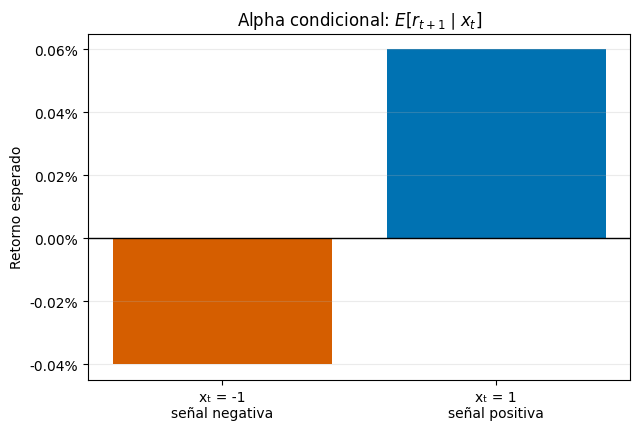

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
n = 10_000

# 1 bp = 0.0001
mu_up = 0.0006     # +6 bps
mu_down = -0.0004  # -4 bps

# Señal observada hoy:
# x_t = 1  -> señal positiva
# x_t = -1 -> señal negativa
x_t = rng.choice(
    [-1, 1],
    size=n,
    p=[0.60, 0.40]
)

# Retorno futuro:
# la media depende de x_t, pero hay ruido no predecible
ruido = rng.normal(loc=0, scale=0.01, size=n)

r_t_plus_1 = np.where(
    x_t == 1,
    mu_up + ruido,
    mu_down + ruido
)

df = pd.DataFrame({
    "x_t": x_t,
    "r_t_plus_1": r_t_plus_1
})

# Retornos condicionales estimados con la simulación
resumen = (
    df.groupby("x_t")["r_t_plus_1"]
    .agg(
        observaciones="count",
        retorno_condicional="mean",
        volatilidad="std"
    )
)

resumen["P(x_t)"] = resumen["observaciones"] / len(df)
resumen["contribucion"] = (
    resumen["P(x_t)"] * resumen["retorno_condicional"]
)

media_total_esperanza = resumen["contribucion"].sum()
media_total_directa = df["r_t_plus_1"].mean()

display(
    resumen.style.format({
        "retorno_condicional": "{:.2%}",
        "volatilidad": "{:.2%}",
        "P(x_t)": "{:.2%}",
        "contribucion": "{:.4%}",
    })
)

print(f"Media directa de r_(t+1): {media_total_directa:.4%}")
print(f"Media por esperanza total: {media_total_esperanza:.4%}")

# Cálculo teórico exacto, sin ruido
media_teorica = 0.40 * mu_up + 0.60 * mu_down

print(f"Media teórica: {media_teorica:.4%}")
print(f"Media condicional si x_t =  1: {mu_up:.2%} = +6 bps")
print(f"Media condicional si x_t = -1: {mu_down:.2%} = -4 bps")

# Visualización
fig, ax = plt.subplots(figsize=(7, 4.5))

valores_teoricos = [mu_down, mu_up]

ax.bar(
    ["xₜ = -1\nseñal negativa", "xₜ = 1\nseñal positiva"],
    valores_teoricos,
    color=["#D55E00", "#0072B2"]
)

ax.axhline(0, color="black", linewidth=1)
ax.set_title(r"Alpha condicional: $E[r_{t+1}\mid x_t]$")
ax.set_ylabel("Retorno esperado")
ax.yaxis.set_major_formatter(lambda valor, _: f"{valor:.2%}")
ax.grid(axis="y", alpha=0.25)

plt.show()

<b> Predictibilidad falsa por look-ahead. </b> 

Simula 5_000 retornos i.i.d. 

Construye dos señales:

`signal_valid[t] = sign(r[t-1])`

`signal_bad[t]   = sign(r[t+1])`

y una estrategia sencilla:

$$ PnL_{t+1}=signal_t\,r_{t+1}. $$

Calcula para ambas únicamente mean pnl, std pnl, annualized Sharpe y % profitable days.

Después dibuja explícitamente la línea temporal:

$$ r_{t-1}
\rightarrow
\boxed{\mathcal F_t}
\rightarrow
\text{signal\_valid}_t
\rightarrow
\text{position}_t
\rightarrow
r_{t+1} $$

Tu explicación final debe contestar:

¿por qué signal_bad puede producir un Sharpe espectacular incluso cuando los retornos fueron generados como ruido puro? No arregles el modelo; encuentra exactamente qué información ilegal utilizaste.

- <b> R: </b> só ilegalmente el retorno futuro para decidir la posición de hoy.

In [1]:
import numpy as np 
import pandas as pd 
import scipy.stats as stats 

# simular 5_000 retornos 
rng = np.random.default_rng(seed = 45)
serie = rng.normal(size = 5_000, scale = 0.01)
# señales 
signal_valid = []
signal_bad = []
retornos_futuros = []

for t in range(1, len(serie)-1): 
    signal_valid.append(np.sign(serie[t-1]))
    signal_bad.append(np.sign(serie[t + 1]))
    retornos_futuros.append(serie[t + 1])

signal_valid = np.array(signal_valid)
signal_bad = np.array(signal_bad)
retornos_futuros = np.array(retornos_futuros)

# PnL_{t+1} = signal_t * r_{t+1}
pnl_valid = signal_valid * retornos_futuros
pnl_bad = signal_bad * retornos_futuros


def metricas_pnl(pnl): 
    return {'mean_pnl': pnl.mean(), 
            'std_pnl': pnl.std(ddof= 1), 
            'sharpe_anualizado': pnl.mean()/pnl.std(ddof= 1) * np.sqrt(252), 
            'profitable_days': (pnl > 0).mean(), }

resultado_valid = metricas_pnl(pnl_valid)
resultado_bad = metricas_pnl(pnl_bad)

df_resultados = pd.DataFrame(
    [resultado_valid, resultado_bad],
    index=["signal_valid", "signal_bad"]
)

df_resultados.style.format({
    "mean_pnl": "{:.4%}",
    "std_pnl": "{:.2%}",
    "annualized_sharpe": "{:.2f}",
    "profitable_days": "{:.2%}",
})


,mean_pnl,std_pnl,sharpe_anualizado,profitable_days
signal_valid,0.0248%,1.01%,0.389653,50.62%
signal_bad,0.8024%,0.61%,20.756304,100.00%


<b> Research + Quant Desk | Construye un Information Set Contract.</b>

Este sí quiero que termine como pieza conceptual de tu desk. Imagina que quieres producir a las 10:00:00 una señal para el retorno 10:00–10:05.

Definimos tabla. 

| Variable              | observation_time | available_time | ¿usable a 10:00? |
| --------------------- | ---------------- | -------------- | ---------------- |
| Last trade            | 09:59:59         | 09:59:59       | ?                |
| 5-min bar 09:55–10:00 | 10:00:00         | 10:00:01       | ?                |
| Fundamental report    | 09:30:00         | 09:32:00       | ?                |
| 10:00–10:05 volume    | 10:05:00         | 10:05:00       | ?                |
| Previous close        | día anterior     | día anterior   | ?                |


Decide cada caso utilizando available_time, no simplemente el timestamp que representa el dato.

<b> Respuesta </b>
1. Es usable 
2. No es usable (Look-ahead bias)
3. Usable 
4. No es usable (Look-ahead bias)
5. Es usable

Después escribe una sola regla que debería cumplir cualquier feature antes de entrar a Alpha:

$$ \boxed{\texttt{available\_time(feature)}\leq \texttt{decision\_time}} $$

MI REGLA :  Una feature solo puede entrar al modelo si su available_time es anterior o igual al instante de decisión.

Finalmente explica por qué observation_time y available_time no son necesariamente iguales.

<b> R:</b> observation_time indica cuándo ocurrió o se registró el evento; available_time indica cuándo el sistema realmente pudo conocer y utilizar ese dato. Pueden diferir por retrasos de publicación, procesamiento, agregación, revisión o entrega del proveedor. Por ejemplo, una barra 09:55–10:00 termina a las 10:00, pero si está disponible a las 10:00:01, no puede usarse para decidir exactamente a las 10:00.

# Martes
> si una feature es temporalmente válida, todavía debemos preguntar qué significa que tenga exposición a un factor

<b> Estadística | Una estrategia rentable que en realidad sólo compra beta. </b>

Simula 1000 días:

> `market = np.random.normal(0.0003, 0.01, 1000)`
>
> `eps    = np.random.normal(0, 0.004, 1000)`
> 
> `strategy = 1.5 * market + eps`

Primero calcula el Sharpe de `strategy`.

Después estima mediante OLS:

$$ r_t^{strategy} = \alpha+\beta r_t^{market}+\varepsilon_t. $$

Obtén solamente:

strategy Sharpe
estimated alpha
estimated beta
residual Sharpe
R²

Ahora crea:

neutralized = strategy - beta_hat * market

y compara su comportamiento con la estrategia original.

No intentes mejorarla.

La pregunta es:

Si la estrategia tenía un Sharpe atractivo antes de neutralizarla y casi ninguno después, ¿qué descubriste realmente sobre tu “alpha”?

Piensa también qué significa \(R^2\) aquí: no como métrica de forecasting, sino como fracción de la variación explicada por la exposición común.

In [ ]:
import numpy as np 
import scipy.stats as stats 
import statsmodels.api as sm 
rng = np.random.default_rng(seed=  42)
mercado = rng.normal(loc = 0, size = 10_000, scale = 0.01)
shocks    = rng.normal(loc = 0, scale = 0.004, size = 10_000)
strategy = 1.5 * mercado + shocks
# Primero calcula el Sharpe de `strategy`.
sharpe = strategy.mean() / strategy.std(ddof=1)
#Después estima mediante OLS:
# r_t^{strategy} = \alpha+\beta r_t^{market}+\varepsilon_t.

